# LLM Inference Benchmark (vLLM)

This notebook benchmarks vLLM inference across four configurations, each run
in its own cell with a **fresh vLLM server instance**:

| Test | Configuration | Description |
|------|--------------|-------------|
| 1 | **Baseline** | Standard vLLM inference, no speculation (chunked prefill ON, 512-token chunks) |
| 2 | **Spec Draft 1B** | Speculative decoding with Llama-3.2-1B draft model |
| 3 | **Spec N-gram** | N-gram (prompt lookup) speculative decoding |
| 4 | **No Chunked Prefill** | Chunked prefill disabled (`--no-enable-chunked-prefill --max-num-batched-tokens 4096`) — 4096-token prefill steps with no decode interleaving; compare TTFT/ITL p99 on `mixed_context` |

## Metrics collected per test
- **Throughput**: Output tokens/s, total tokens/s, requests/s
- **Latency**: TTFT p50/p95/p99, ITL p50/p95/p99, request latency
- **Goodput**: Successful tokens/s, success rate, SLA compliance
- **KV Cache**: Utilization %, prefix cache hit rate

## Workloads
- `random_short` — Short prompts (<100 tokens), tests raw decode speed
- `random_medium` — Medium prompts (100-500 tokens), balanced workload
- `long_context` — Long prompts (500-1500 tokens), stresses prefill throughput
- `mixed_context` — 50% very-long (≥800 tokens) + 50% very-short (<50 tokens), **interleaved** so every batch slice has both types; tests chunked-prefill head-of-line blocking (key metric: TTFT p99)
- `shared_prefix` — Same prefix + different questions, tests KV cache reuse
- `repetitive` — Repetitive patterns, tests n-gram speculation
- `code` — Code generation, tests structured output speculation

Each test saves its own DataFrame and CSV. After all tests, comprehensive
comparison graphs are generated.

---
## 1. Install Dependencies

In [ ]:
# Install required packages
!pip uninstall -y protobuf -q
!pip install "protobuf>=4.25,<5.0" -q
!pip install "vllm>=0.6.3" "openai>=1.51.0" "transformers>=4.44.2" \
    "tokenizers>=0.19.1" "accelerate" "GPUtil" "httpx>=0.27" "pandas" \
    "psutil" "torch" "gpustat" "nvidia-ml-py" "seaborn" "matplotlib" \
    "huggingface_hub" "datasets" "aiohttp" "nest_asyncio" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 23.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.1/98.1 kB 9.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
   

## 2. Hugging Face Authentication

In [ ]:
import os

os.environ["HF_TOKEN"] = 'YOUR_HF_TOKEN_HERE'

from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 3. Download Models

Downloads the target model and the draft model used for speculative decoding.

In [ ]:
from huggingface_hub import snapshot_download

target_model = "meta-llama/Llama-3.2-3B-Instruct"
draft_model = "meta-llama/Llama-3.2-1B-Instruct"

print(f"Downloading {target_model}...")
snapshot_download(target_model)
print(f"Downloading {draft_model}...")
snapshot_download(draft_model)
print("All models downloaded.")

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

LICENSE.txt: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

original/tokenizer.model:   0%|          | 0.00/2.18M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

All models downloaded.


## 4. Upload Benchmark Module

Upload the `llm_benchmark/` folder to your Colab environment.

In [ ]:
import os

required_files = [
    "llm_benchmark/__init__.py",
    "llm_benchmark/benchmark_core.py",
    "llm_benchmark/server.py",
    "llm_benchmark/workloads.py",
    "llm_benchmark/metrics.py",
    "llm_benchmark/stats.py",
    "llm_benchmark/runner.py",
]

missing = [f for f in required_files if not os.path.exists(f)]
if missing:
    print("Missing files:")
    for f in missing:
        print(f"  - {f}")
    print("\nPlease upload the llm_benchmark folder.")
else:
    print("llm_benchmark module found. All files present.")

llm_benchmark module found. All files present.


## 4b. Dataset File Configuration

Both vLLM and SGLang notebooks share the same prompts via a JSON dataset file.
- If the file exists, prompts are loaded from it (ensuring identical inputs across engines).
- If it does not exist, prompts are generated from the Dolly dataset and saved to the file.

Set `DATASET_FILE` below to control the path. Upload the file to Colab, or
leave the default to auto-generate on first run.

In [ ]:
import os

# Path to the shared dataset file.
# Both vLLM and SGLang notebooks should point to the SAME file.
DATASET_FILE = "benchmark_prompts.json"

# Set to False to disable KV cache metric polling during benchmarks.
# When disabled, KV cache columns will report 0 / NaN instead of
# polling the server's /metrics endpoint every second.
COLLECT_KV_STATS = False

if os.path.exists(DATASET_FILE):
    print(f"Dataset file found: {DATASET_FILE}")
    print(f"  Size: {os.path.getsize(DATASET_FILE) / 1024:.1f} KB")
    print("  Prompts will be loaded from this file.")
else:
    print(f"Dataset file not found: {DATASET_FILE}")
    print("  Prompts will be generated and saved to this file.")
    print("  Tip: Upload a previously generated file to use identical prompts across runs.")

Dataset file found: benchmark_prompts.json
  Size: 2236.7 KB
  Prompts will be loaded from this file.


## 5. Initialize Benchmark Environment

This cell:
1. Detects GPU and selects optimal dtype
2. Loads the tokenizer (shared across all tests)
3. Loads workloads from a shared dataset file (or generates & saves one)
4. Defines the `run_single_config()` helper used by each test cell

In [ ]:
import time
import pandas as pd
import numpy as np
from transformers import AutoTokenizer

from llm_benchmark import (
    detect_gpu,
    pick_dtype,
    ServerConfig,
    ServerProcess,
    WorkloadGenerator,
    WORKLOAD_CONFIGS,
    run_workload,
    TestConfig,
    VLLM_TEST_CONFIGS,
    DEFAULT_BATCH_SIZES,
    StatisticsReporter,
)

# ---- Shared state (computed once, used by every test cell) ----
MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"
BATCH_SIZES = DEFAULT_BATCH_SIZES          # [1, 8, 32, 64]
WORKLOAD_NAMES = list(WORKLOAD_CONFIGS.keys())

# Per-workload batch-size caps (prevents OOM / server stalls).
MAX_BATCH = {
    "shared_prefix": 64,   # Long shared prefix exhausts KV cache at high batch
    "repetitive": 8,       # vLLM stalls with many concurrent long-output requests
    "long_context": 32,    # 500-1500 token prompts use significant KV cache
    "mixed_context": 64,   # Half long (>=1500 tok) prompts; cap matches long_context
}

gpu_info = detect_gpu()
dtype = pick_dtype(gpu_info)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

workload_gen = WorkloadGenerator(MODEL_ID)

# --- Load or generate workloads ---
if os.path.exists(DATASET_FILE):
    workload_gen.load_workloads(DATASET_FILE)
    print(f"\n✅ Loaded prompts from {DATASET_FILE}")
else:
    workload_gen.prepare_workloads(
        n_random=max(BATCH_SIZES),
        n_shared=max(BATCH_SIZES),
    )
    workload_gen.save_workloads(DATASET_FILE)
    print(f"\n💾 Generated and saved prompts to {DATASET_FILE}")

print(f"\nGPU: {gpu_info['name']} ({gpu_info['memory_gb']:.1f} GB, CC {gpu_info['cc']})")
print(f"Dtype: {dtype}")
print(f"Batch sizes: {BATCH_SIZES}")
print(f"Workloads: {list(workload_gen._workloads.keys())}")


def run_single_config(
    config: TestConfig,
    batch_sizes=None,
    workload_names=None,
    warmup: int = 3,
) -> pd.DataFrame:
    """
    For *config*, start a FRESH vLLM server for EACH workload, run every
    batch size against it, then shut it down before moving to the next
    workload.  This isolates workloads so a crash, OOM, or KV cache
    fragmentation in one cannot affect the next.

    All rows still go into a single reporter and one CSV — same output
    shape as before.  Cost: one extra server start per workload (~30-60 s
    each on an L4), so 9 workloads ≈ 9 startups per config.
    """
    batch_sizes = batch_sizes or BATCH_SIZES
    workload_names = workload_names or WORKLOAD_NAMES
    reporter = StatisticsReporter()

    # -- build server launch args (same for every workload) --
    extra_args = list(config.extra_args)
    if config.spec_config:
        extra_args.extend(["--speculative-config", config.spec_config])

    for wl_name in workload_names:
        wl_cfg = WORKLOAD_CONFIGS[wl_name]
        prompts = workload_gen.get_workload(wl_name)
        if not prompts:
            print(f"\n=== {wl_name} — SKIPPED (no prompts loaded) ===")
            continue
        cap = MAX_BATCH.get(wl_name, float("inf"))

        print(f"\n{'=' * 60}")
        print(f"Workload: {wl_name} — {wl_cfg.description}")
        print(f"{'=' * 60}")

        # Fresh server for this workload
        server_cfg = ServerConfig(
            engine=config.engine,
            model_id=MODEL_ID,
            port=8000,
            dtype=dtype,
            gpu_mem_util=config.gpu_mem_util,
            max_model_len=8192,
            extra_args=extra_args,
        )
        server = ServerProcess(server_cfg)
        try:
            server.start()
        except Exception as e:
            print(f"  Server failed to start for {wl_name}: {e}")
            continue

        try:
            # Warmup the fresh server
            if warmup > 0:
                print("  Warming up...")
                wp = workload_gen.get_workload("random_short")[:warmup]
                _ = run_workload(
                    base_url=server_cfg.base_url(),
                    model=MODEL_ID,
                    prompts=wp,
                    tokenizer=tokenizer,
                    concurrency=warmup,
                    max_tokens=32,
                    collect_kv_stats=COLLECT_KV_STATS,
                )

            # Run every batch size on this server
            for bs in batch_sizes:
                if bs > cap:
                    print(f"    Batch {bs:>4d} ... skipped (cap {int(cap)} for {wl_name})")
                    continue

                print(f"    Batch {bs:>4d} ... ", end="", flush=True)
                try:
                    bm = run_workload(
                        base_url=server_cfg.base_url(),
                        model=MODEL_ID,
                        prompts=prompts[:bs],
                        tokenizer=tokenizer,
                        concurrency=bs,
                        max_tokens=wl_cfg.max_tokens,
                        temperature=wl_cfg.temperature,
                        collect_kv_stats=COLLECT_KV_STATS,
                    )
                    reporter.add_run(
                        config_name=config.name,
                        workload_name=wl_name,
                        batch_size=bs,
                        batch_metrics=bm,
                    )
                    tp = bm.throughput_output_tok_s
                    print(f"{tp:,.1f} tok/s  ({bm.successful_requests}/{bm.total_requests} ok)")
                except Exception as e:
                    print(f"ERROR: {e}")
        finally:
            server.stop()

    df = reporter.to_dataframe()
    csv_name = f"results_{config.name}.csv"
    df.to_csv(csv_name, index=False)
    print(f"\n  Saved {len(df)} rows → {csv_name}")
    return df



📊 Workload Statistics:
------------------------------------------------------------
  random_short:
    Prompts: 64
    Tokens - min: 1, max: 4, mean: 3.7, median: 4.0
  random_medium:
    Prompts: 64
    Tokens - min: 100, max: 103, mean: 101.2, median: 101.0
  long_context:
    Prompts: 64
    Tokens - min: 500, max: 534, mean: 517.4, median: 517.0
  mixed_context:
    Prompts: 64
    Tokens - min: 1, max: 6228, mean: 3056.2, median: 3008.0
  shared_prefix:
    Prompts: 64
    Tokens - min: 318, max: 325, mean: 320.6, median: 320.0
  repetitive:
    Prompts: 64
    Tokens - min: 9, max: 27, mean: 15.4, median: 15.5
  code:
    Prompts: 64
    Tokens - min: 9, max: 16, mean: 12.4, median: 11.5
  sharegpt:
    Prompts: 256
    Tokens - min: 256, max: 763, mean: 458.5, median: 424.5
  sonnet:
    Prompts: 256
    Tokens - min: 550, max: 550, mean: 550.0, median: 550.0
------------------------------------------------------------

✅ Loaded prompts from benchmark_prompts.json

GPU: NVIDIA

---
## 6. Test 1 — Baseline (No Speculation)

Starts a fresh vLLM server with standard inference (no speculative decoding),
runs all workloads and batch sizes, then shuts down.

In [ ]:
# --- Quick isolation test: code workload only ---
# Run this AFTER the initialization cell (cell-10) to test a single
# workload in isolation with a fresh server.

config_baseline = VLLM_TEST_CONFIGS[0]  # baseline

df_share_sonnet = run_single_config(
    config_baseline,
    batch_sizes=[1, 8, 16, 32, 64],
    workload_names=["sharegpt", "sonnet"],
)
print(df_share_sonnet)


Workload: sharegpt — Real ChatGPT conversations (ShareGPT) - diverse real-world prompt distribution

🚀 Starting vLLM server on port 8000:
   python -m vllm.entrypoints.openai.api_server --model meta-llama/Llama-3.2-3B-Instruct --host 0.0.0.0 --port 8000 --dtype bfloat16 --gpu-memory-utilization 0.9 --max-model-len 8192
  [vllm] 2026-04-16 05:02:25.151362: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
  [vllm] 2026-04-16 05:02:25.170173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
  [vllm] WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
  [vllm] E0000 00:00:1776315745.195099    9259 cuda_dnn.cc:8

KeyboardInterrupt: 

In [ ]:
print("=" * 60)
print("TEST 1: Baseline (no speculation)")
print("=" * 60)

config_baseline = VLLM_TEST_CONFIGS[0]  # "baseline"
df_baseline = run_single_config(config_baseline)

df_baseline.to_csv("results_baseline.csv", index=False)
print(f"\nSaved {len(df_baseline)} rows -> results_baseline.csv")
df_baseline

TEST 1: Baseline (no speculation)

Workload: random_short — Short prompts (<100 tokens) - tests raw decode speed

🚀 Starting vLLM server on port 8000:
   python -m vllm.entrypoints.openai.api_server --model meta-llama/Llama-3.2-3B-Instruct --host 0.0.0.0 --port 8000 --dtype bfloat16 --gpu-memory-utilization 0.9 --max-model-len 8192
  [vllm] 2026-04-16 05:04:34.651287: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
  [vllm] 2026-04-16 05:04:34.670316: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
  [vllm] WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
  [vllm] E0000 00:00:1776315874.694425   10082 c

,run_id,timestamp,config_name,workload_name,batch_size,throughput_output_tok_s,throughput_total_tok_s,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,...,goodput_goodput_requests_s,goodput_success_rate,goodput_timeout_rate,goodput_error_rate,goodput_effective_batch_utilization,goodput_throughput_per_watt,goodput_sla_ttft_target_ms,goodput_sla_compliance_rate,speedup_vs_baseline,error_message
0,baseline_random_short_1_1776315934,2026-04-16T05:05:34.192417,baseline,random_short,1,160.80,338.53,17.19,17.19,17.19,...,4.232,100.0,0.0,0.0,99.47,0.0,500.0,100.00,NaN,
1,baseline_random_short_8_1776315935,2026-04-16T05:05:35.075192,baseline,random_short,8,955.61,1351.03,45.24,47.24,47.54,...,9.090,100.0,0.0,0.0,81.30,0.0,500.0,100.00,NaN,
2,baseline_random_short_32_1776315936,2026-04-16T05:05:36.005104,baseline,random_short,32,4043.20,5575.86,80.18,88.20,89.14,...,34.539,100.0,0.0,0.0,89.38,0.0,500.0,100.00,NaN,
3,baseline_random_short_64_1776315937,2026-04-16T05:05:37.103399,baseline,random_short,64,6957.87,9572.79,128.63,139.88,141.94,...,58.516,100.0,0.0,0.0,89.66,0.0,500.0,100.00,NaN,
4,baseline_random_medium_1_1776316005,2026-04-16T05:06:45.464775,baseline,random_medium,1,162.61,750.53,18.06,18.06,18.06,...,4.170,100.0,0.0,0.0,99.23,0.0,500.0,100.00,NaN,
5,baseline_random_medium_8_1776316006,2026-04-16T05:06:46.327353,baseline,random_medium,8,543.11,1854.93,60.42,63.62,63.94,...,9.304,100.0,0.0,0.0,49.24,0.0,500.0,100.00,NaN,
6,baseline_random_medium_32_1776316007,2026-04-16T05:06:47.320466,baseline,random_medium,32,1905.08,6478.89,148.49,160.08,161.14,...,32.324,100.0,0.0,0.0,52.51,0.0,500.0,100.00,NaN,
7,baseline_random_medium_64_1776316008,2026-04-16T05:06:48.438730,baseline,random_medium,64,3681.63,11846.89,174.01,220.68,222.97,...,57.413,100.0,0.0,0.0,58.88,0.0,500.0,100.00,NaN,
8,baseline_long_context_1_1776316076,2026-04-16T05:07:56.730692,baseline,long_context,1,143.17,3370.36,29.76,29.76,29.76,...,5.965,100.0,0.0,0.0,97.60,0.0,500.0,100.00,NaN,
9,baseline_long_context_8_1776316077,2026-04-16T05:07:57.718923,baseline,long_context,8,654.45,5057.00,140.25,145.19,145.84,...,8.117,100.0,0.0,0.0,66.62,0.0,500.0,100.00,NaN,


## 7. Test 2 — Speculative Decoding (Draft Model 1B)

Starts a fresh vLLM server with a 1B draft model for speculative decoding
(5 speculative tokens). GPU memory utilization is reduced to 85% to
accommodate both models.

In [ ]:
print("=" * 60)
print("TEST 2: Speculative decoding -- draft model (1B)")
print("=" * 60)

config_draft = VLLM_TEST_CONFIGS[1]  # "spec_draft_1b"
df_spec_draft = run_single_config(config_draft)

df_spec_draft.to_csv("results_spec_draft_1b.csv", index=False)
print(f"\nSaved {len(df_spec_draft)} rows -> results_spec_draft_1b.csv")
df_spec_draft

TEST 2: Speculative decoding -- draft model (1B)

Workload: random_short — Short prompts (<100 tokens) - tests raw decode speed

🚀 Starting vLLM server on port 8000:
   python -m vllm.entrypoints.openai.api_server --model meta-llama/Llama-3.2-3B-Instruct --host 0.0.0.0 --port 8000 --dtype bfloat16 --gpu-memory-utilization 0.85 --max-model-len 8192 --speculative-config {"method": "draft_model", "model": "meta-llama/Llama-3.2-1B-Instruct", "num_speculative_tokens": 3}
  [vllm] 2026-04-16 05:16:22.173209: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
  [vllm] 2026-04-16 05:16:22.192200: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
  [vllm

,run_id,timestamp,config_name,workload_name,batch_size,throughput_output_tok_s,throughput_total_tok_s,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,...,goodput_goodput_requests_s,goodput_success_rate,goodput_timeout_rate,goodput_error_rate,goodput_effective_batch_utilization,goodput_throughput_per_watt,goodput_sla_ttft_target_ms,goodput_sla_compliance_rate,speedup_vs_baseline,error_message
0,spec_draft_1b_random_short_1_1776316673,2026-04-16T05:17:53.473323,spec_draft_1b,random_short,1,84.91,176.35,47.75,47.75,47.75,...,2.177,100.0,0.0,0.0,99.73,0.0,500.0,100.00,NaN,
1,spec_draft_1b_random_short_8_1776316675,2026-04-16T05:17:55.526160,spec_draft_1b,random_short,8,410.20,579.94,430.44,432.15,432.31,...,3.902,100.0,0.0,0.0,81.56,0.0,500.0,100.00,NaN,
2,spec_draft_1b_random_short_32_1776316677,2026-04-16T05:17:57.455474,spec_draft_1b,random_short,32,1949.56,2686.81,322.06,330.70,331.30,...,16.614,100.0,0.0,0.0,82.79,0.0,500.0,100.00,NaN,
3,spec_draft_1b_random_short_64_1776316679,2026-04-16T05:17:59.349925,spec_draft_1b,random_short,64,4023.01,5535.34,172.50,188.64,190.98,...,33.842,100.0,0.0,0.0,78.65,0.0,500.0,100.00,NaN,
4,spec_draft_1b_random_medium_1_1776316759,2026-04-16T05:19:19.096744,spec_draft_1b,random_medium,1,79.39,251.60,147.04,147.04,147.04,...,1.221,100.0,0.0,0.0,99.71,0.0,500.0,100.00,NaN,
5,spec_draft_1b_random_medium_8_1776316760,2026-04-16T05:19:20.453256,spec_draft_1b,random_medium,8,334.58,1167.72,109.79,112.97,113.32,...,5.909,100.0,0.0,0.0,49.71,0.0,500.0,100.00,NaN,
6,spec_draft_1b_random_medium_32_1776316762,2026-04-16T05:19:22.342050,spec_draft_1b,random_medium,32,1001.13,3402.15,261.59,316.22,318.20,...,16.968,100.0,0.0,0.0,48.06,0.0,500.0,100.00,NaN,
7,spec_draft_1b_random_medium_64_1776316764,2026-04-16T05:19:24.386520,spec_draft_1b,random_medium,64,2064.17,6523.73,231.61,322.82,326.04,...,31.357,100.0,0.0,0.0,48.98,0.0,500.0,100.00,NaN,
8,spec_draft_1b_long_context_1_1776316844,2026-04-16T05:20:44.259406,spec_draft_1b,long_context,1,61.42,1390.59,168.29,168.29,168.29,...,2.457,100.0,0.0,0.0,99.10,0.0,500.0,100.00,NaN,
9,spec_draft_1b_long_context_8_1776316845,2026-04-16T05:20:45.880526,spec_draft_1b,long_context,8,375.66,3056.58,272.26,312.28,313.07,...,4.943,100.0,0.0,0.0,65.82,0.0,500.0,100.00,NaN,


## 8. Test 3 — Speculative Decoding (N-gram / Prompt Lookup)

Starts a fresh vLLM server with n-gram speculation (prompt-lookup,
5 speculative tokens, max window 4). No extra model needed.

In [ ]:
print("=" * 60)
print("TEST 3: Speculative decoding -- n-gram (prompt lookup)")
print("=" * 60)

config_ngram = VLLM_TEST_CONFIGS[2]  # "spec_ngram"
df_spec_ngram = run_single_config(config_ngram)

df_spec_ngram.to_csv("results_spec_ngram.csv", index=False)
print(f"\nSaved {len(df_spec_ngram)} rows -> results_spec_ngram.csv")
df_spec_ngram

TEST 3: Speculative decoding -- n-gram (prompt lookup)

Workload: random_short — Short prompts (<100 tokens) - tests raw decode speed

🚀 Starting vLLM server on port 8000:
   python -m vllm.entrypoints.openai.api_server --model meta-llama/Llama-3.2-3B-Instruct --host 0.0.0.0 --port 8000 --dtype bfloat16 --gpu-memory-utilization 0.9 --max-model-len 8192 --speculative-config {"method": "ngram", "num_speculative_tokens": 5, "prompt_lookup_max": 4}
  [vllm] 2026-04-16 14:00:43.692788: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
  [vllm] 2026-04-16 14:00:43.711158: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
  [vllm] WARNING: All log mes

,run_id,timestamp,config_name,workload_name,batch_size,throughput_output_tok_s,throughput_total_tok_s,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,...,goodput_goodput_requests_s,goodput_success_rate,goodput_timeout_rate,goodput_error_rate,goodput_effective_batch_utilization,goodput_throughput_per_watt,goodput_sla_ttft_target_ms,goodput_sla_compliance_rate,speedup_vs_baseline,error_message
0,spec_ngram_random_short_1_1776348155,2026-04-16T14:02:35.801423,spec_ngram,random_short,1,119.82,252.25,15.34,15.34,15.34,...,3.153,100.0,0.0,0.0,99.64,0.0,500.0,100.00,NaN,
1,spec_ngram_random_short_8_1776348160,2026-04-16T14:02:40.401448,spec_ngram,random_short,8,182.93,258.63,3358.15,3360.26,3360.44,...,1.740,100.0,0.0,0.0,94.51,0.0,500.0,12.50,NaN,
2,spec_ngram_random_short_32_1776348165,2026-04-16T14:02:45.255155,spec_ngram,random_short,32,773.33,1066.09,3413.60,3421.63,3422.04,...,6.597,100.0,0.0,0.0,97.05,0.0,500.0,6.25,NaN,
3,spec_ngram_random_short_64_1776348166,2026-04-16T14:02:46.880047,spec_ngram,random_short,64,4713.21,6477.81,125.42,138.76,140.55,...,39.488,100.0,0.0,0.0,90.33,0.0,500.0,100.00,NaN,
4,spec_ngram_random_medium_1_1776348237,2026-04-16T14:03:57.074319,spec_ngram,random_medium,1,168.00,538.13,16.18,16.18,16.18,...,2.625,100.0,0.0,0.0,99.56,0.0,500.0,100.00,NaN,
5,spec_ngram_random_medium_8_1776348238,2026-04-16T14:03:58.023721,spec_ngram,random_medium,8,510.19,1701.70,60.69,63.60,63.92,...,8.450,100.0,0.0,0.0,49.10,0.0,500.0,100.00,NaN,
6,spec_ngram_random_medium_32_1776348239,2026-04-16T14:03:59.306354,spec_ngram,random_medium,32,1436.19,4974.30,138.35,148.93,150.00,...,25.004,100.0,0.0,0.0,45.86,0.0,500.0,100.00,NaN,
7,spec_ngram_random_medium_64_1776348240,2026-04-16T14:04:00.918956,spec_ngram,random_medium,64,2650.61,8307.33,148.44,216.47,218.21,...,39.775,100.0,0.0,0.0,52.89,0.0,500.0,100.00,NaN,
8,spec_ngram_long_context_1_1776348310,2026-04-16T14:05:10.892185,spec_ngram,long_context,1,113.10,2560.50,27.99,27.99,27.99,...,4.524,100.0,0.0,0.0,98.78,0.0,500.0,100.00,NaN,
9,spec_ngram_long_context_8_1776348312,2026-04-16T14:05:12.205804,spec_ngram,long_context,8,487.40,3796.96,114.38,140.15,140.68,...,6.102,100.0,0.0,0.0,56.67,0.0,500.0,100.00,NaN,


## 8. Test 4 — No Chunked Prefill

Starts a fresh vLLM server with `--no-enable-chunked-prefill --max-num-batched-tokens 4096`
(requires vLLM ≥ 0.5).

Without chunking, vLLM processes up to **4096 tokens of prefill per step** as a single
block — several long (≥800-token) requests get prefilled together before any decode step
runs. The baseline uses **512-token prefill chunks** (the default when chunked prefill is
ON), interleaving decode steps between chunks.

Compare this config against **baseline** on the `mixed_context` workload.
The key metrics to look at are:

- **TTFT p99** — the unluckiest short request, which in `no_chunked_prefill` must wait
  for a full 4096-token prefill batch to complete before its own prefill is scheduled
- **ITL p99** — late decode steps can still be delayed by ongoing large prefill steps
- **Throughput** — coarse measure; TTFT/ITL percentiles are the primary signal here

In [ ]:
print("=" * 60)
print("TEST 4: No chunked prefill (disabled)")
print("=" * 60)

config_no_chunked = VLLM_TEST_CONFIGS[3]  # "no_chunked_prefill"
df_no_chunked = run_single_config(config_no_chunked)

df_no_chunked.to_csv("results_no_chunked_prefill.csv", index=False)
print(f"\nSaved {len(df_no_chunked)} rows -> results_no_chunked_prefill.csv")
df_no_chunked

TEST 4: No chunked prefill (disabled)

Workload: random_short — Short prompts (<100 tokens) - tests raw decode speed

🚀 Starting vLLM server on port 8000:
   python -m vllm.entrypoints.openai.api_server --model meta-llama/Llama-3.2-3B-Instruct --host 0.0.0.0 --port 8000 --dtype bfloat16 --gpu-memory-utilization 0.9 --max-model-len 8192 --max-num-batched-tokens 8192
  [vllm] 2026-04-16 14:13:33.129031: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
  [vllm] 2026-04-16 14:13:33.148168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
  [vllm] WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
  [vllm] E0000

,run_id,timestamp,config_name,workload_name,batch_size,throughput_output_tok_s,throughput_total_tok_s,ttft_p50_ms,ttft_p95_ms,ttft_p99_ms,...,goodput_goodput_requests_s,goodput_success_rate,goodput_timeout_rate,goodput_error_rate,goodput_effective_batch_utilization,goodput_throughput_per_watt,goodput_sla_ttft_target_ms,goodput_sla_compliance_rate,speedup_vs_baseline,error_message
0,no_chunked_prefill_random_short_1_1776348883,2026-04-16T14:14:43.942027,no_chunked_prefill,random_short,1,162.95,343.05,17.25,17.25,17.25,...,4.288,100.0,0.0,0.0,99.53,0.0,500.0,100.00,NaN,
1,no_chunked_prefill_random_short_8_1776348884,2026-04-16T14:14:44.817894,no_chunked_prefill,random_short,8,963.31,1361.93,40.57,42.66,42.85,...,9.164,100.0,0.0,0.0,81.36,0.0,500.0,100.00,NaN,
2,no_chunked_prefill_random_short_32_1776348885,2026-04-16T14:14:45.752386,no_chunked_prefill,random_short,32,4026.01,5550.94,84.42,92.60,93.18,...,34.364,100.0,0.0,0.0,89.50,0.0,500.0,100.00,NaN,
3,no_chunked_prefill_random_short_64_1776348886,2026-04-16T14:14:46.845931,no_chunked_prefill,random_short,64,6985.64,9610.99,119.70,128.23,130.06,...,58.749,100.0,0.0,0.0,89.68,0.0,500.0,100.00,NaN,
4,no_chunked_prefill_random_medium_1_1776348955,2026-04-16T14:15:55.256284,no_chunked_prefill,random_medium,1,160.73,741.81,18.31,18.31,18.31,...,4.121,100.0,0.0,0.0,99.16,0.0,500.0,100.00,NaN,
5,no_chunked_prefill_random_medium_8_1776348956,2026-04-16T14:15:56.115945,no_chunked_prefill,random_medium,8,536.78,1853.06,60.38,62.18,62.40,...,9.335,100.0,0.0,0.0,48.65,0.0,500.0,100.00,NaN,
6,no_chunked_prefill_random_medium_32_1776348957,2026-04-16T14:15:57.107188,no_chunked_prefill,random_medium,32,1924.86,6507.28,151.55,162.29,163.48,...,32.385,100.0,0.0,0.0,52.88,0.0,500.0,100.00,NaN,
7,no_chunked_prefill_random_medium_64_1776348958,2026-04-16T14:15:58.214972,no_chunked_prefill,random_medium,64,3841.48,12084.08,179.65,223.30,224.60,...,57.957,100.0,0.0,0.0,59.97,0.0,500.0,100.00,NaN,
8,no_chunked_prefill_long_context_1_1776349026,2026-04-16T14:17:06.306733,no_chunked_prefill,long_context,1,143.17,3370.47,29.76,29.76,29.76,...,5.965,100.0,0.0,0.0,97.79,0.0,500.0,100.00,NaN,
9,no_chunked_prefill_long_context_8_1776349027,2026-04-16T14:17:07.290145,no_chunked_prefill,long_context,8,657.69,5082.04,137.51,140.68,141.23,...,8.157,100.0,0.0,0.0,66.53,0.0,500.0,100.00,NaN,


In [ ]:
import time, pandas as pd, numpy as np
df_baseline = pd.read_csv("results_baseline.csv")
df_spec_draft = pd.read_csv("results_spec_draft_1b.csv")
# Combine all configs
df_all = pd.concat(
    [df_baseline, df_spec_draft, df_spec_ngram, df_no_chunked],
    ignore_index=True,
)

# Build baseline throughput lookup
bl = df_baseline.set_index(["workload_name", "batch_size"])["throughput_output_tok_s"]

def _speedup(row):
    key = (row["workload_name"], row["batch_size"])
    base = bl.get(key, None)
    if base and base > 0:
        return round(row["throughput_output_tok_s"] / base, 3)
    return np.nan

df_all["speedup_vs_baseline"] = df_all.apply(_speedup, axis=1)

ts = time.strftime("%Y%m%d_%H%M%S")
combined_csv = f"results_combined_{ts}.csv"
df_all.to_csv(combined_csv, index=False)
print(f"Combined {len(df_all)} rows -> {combined_csv}")
print(f"Configs : {sorted(df_all['config_name'].unique())}")
print(f"Workloads: {sorted(df_all['workload_name'].unique())}")
df_all[["config_name", "workload_name", "batch_size",
        "throughput_output_tok_s", "ttft_p50_ms", "itl_p50_ms",
        "speedup_vs_baseline"]]

Combined 132 rows -> results_combined_20260416_142934.csv
Configs : ['baseline', 'no_chunked_prefill', 'spec_draft_1b', 'spec_ngram']
Workloads: ['code', 'long_context', 'mixed_context', 'random_medium', 'random_short', 'repetitive', 'shared_prefix', 'sharegpt', 'sonnet']


,config_name,workload_name,batch_size,throughput_output_tok_s,ttft_p50_ms,itl_p50_ms,speedup_vs_baseline
0,baseline,random_short,1,160.80,17.19,5.84,1.000
1,baseline,random_short,8,955.61,45.24,6.54,1.000
2,baseline,random_short,32,4043.20,80.18,6.43,1.000
3,baseline,random_short,64,6957.87,128.63,7.15,1.000
4,baseline,random_medium,1,162.61,18.06,5.82,1.000
...,...,...,...,...,...,...,...
127,no_chunked_prefill,sharegpt,64,4938.44,247.21,9.16,1.019
128,no_chunked_prefill,sonnet,1,163.91,35.61,5.93,0.998
129,no_chunked_prefill,sonnet,8,1069.41,143.62,6.53,1.014
130,no_chunked_prefill,sonnet,32,2834.31,474.87,7.99,1.010


---
# Comparison & Visualization

The cells below graph every key metric across the five configurations
and six workloads.  All plots pull from `df_all`.

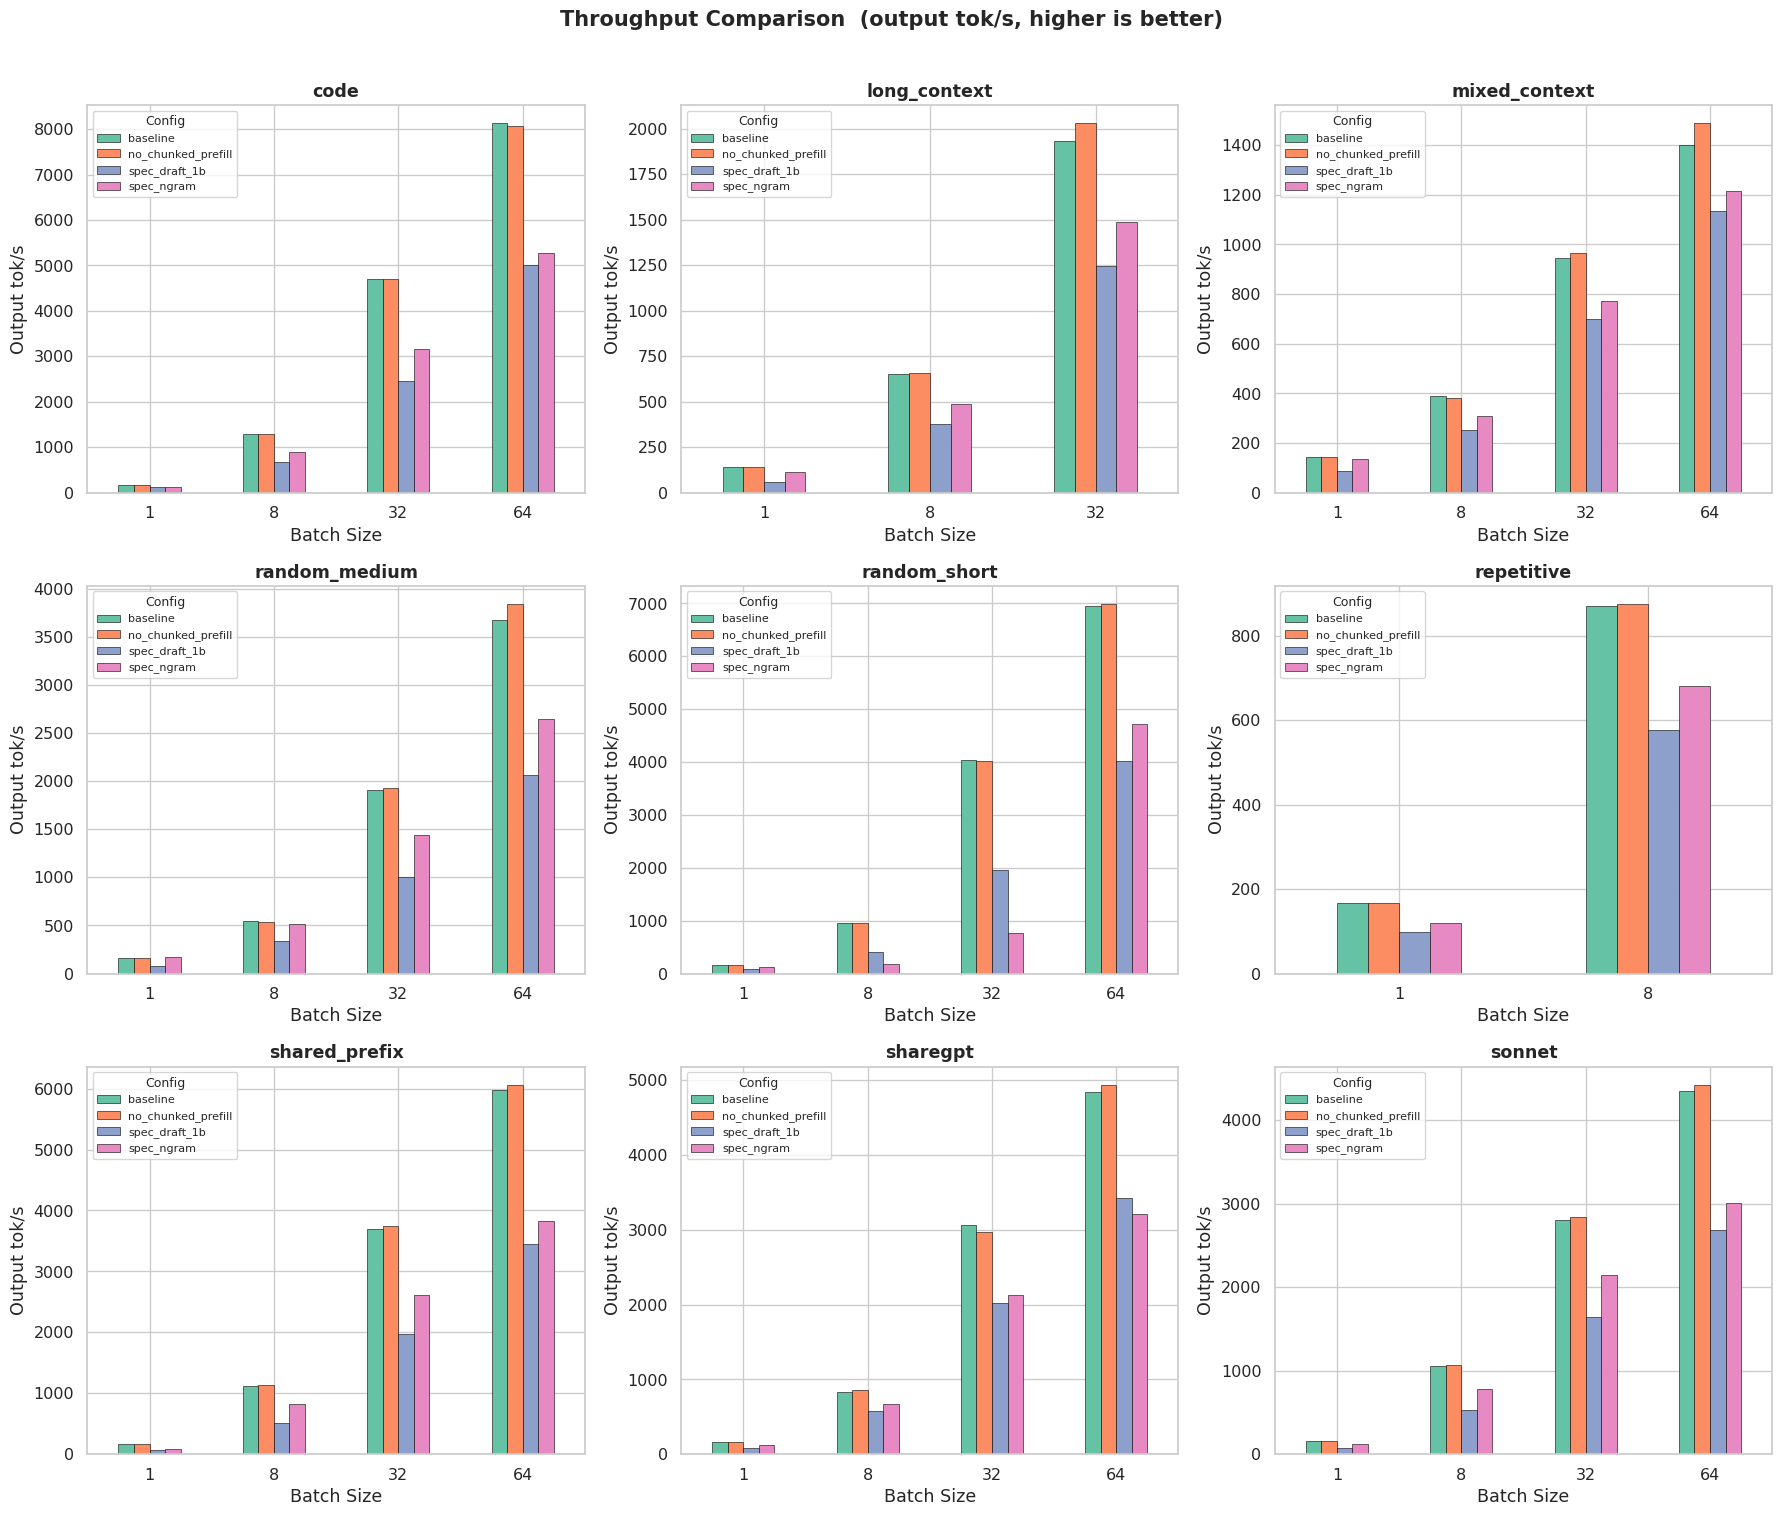

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = sns.color_palette("Set2", n_colors=df_all["config_name"].nunique())
CONFIG_ORDER = sorted(df_all["config_name"].unique())

workloads = sorted(df_all["workload_name"].unique())
n_wl = len(workloads)
ncols = min(3, n_wl)
nrows = (n_wl + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),
                         squeeze=False)

for idx, wl in enumerate(workloads):
    ax = axes[idx // ncols][idx % ncols]
    sub = df_all[df_all["workload_name"] == wl].copy()
    pivot = sub.pivot_table(
        index="batch_size", columns="config_name",
        values="throughput_output_tok_s", aggfunc="first",
    ).reindex(columns=CONFIG_ORDER)
    pivot.plot.bar(ax=ax, color=PALETTE[:len(CONFIG_ORDER)], edgecolor="black",
                   linewidth=0.4)
    ax.set_title(wl, fontweight="bold")
    ax.set_ylabel("Output tok/s")
    ax.set_xlabel("Batch Size")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Config", fontsize=8, title_fontsize=9)

# hide unused subplots
for idx in range(n_wl, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Throughput Comparison  (output tok/s, higher is better)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_throughput.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Time-to-First-Token (TTFT) Comparison

TTFT at p50, p95, and p99 for each workload.  Lower is better.

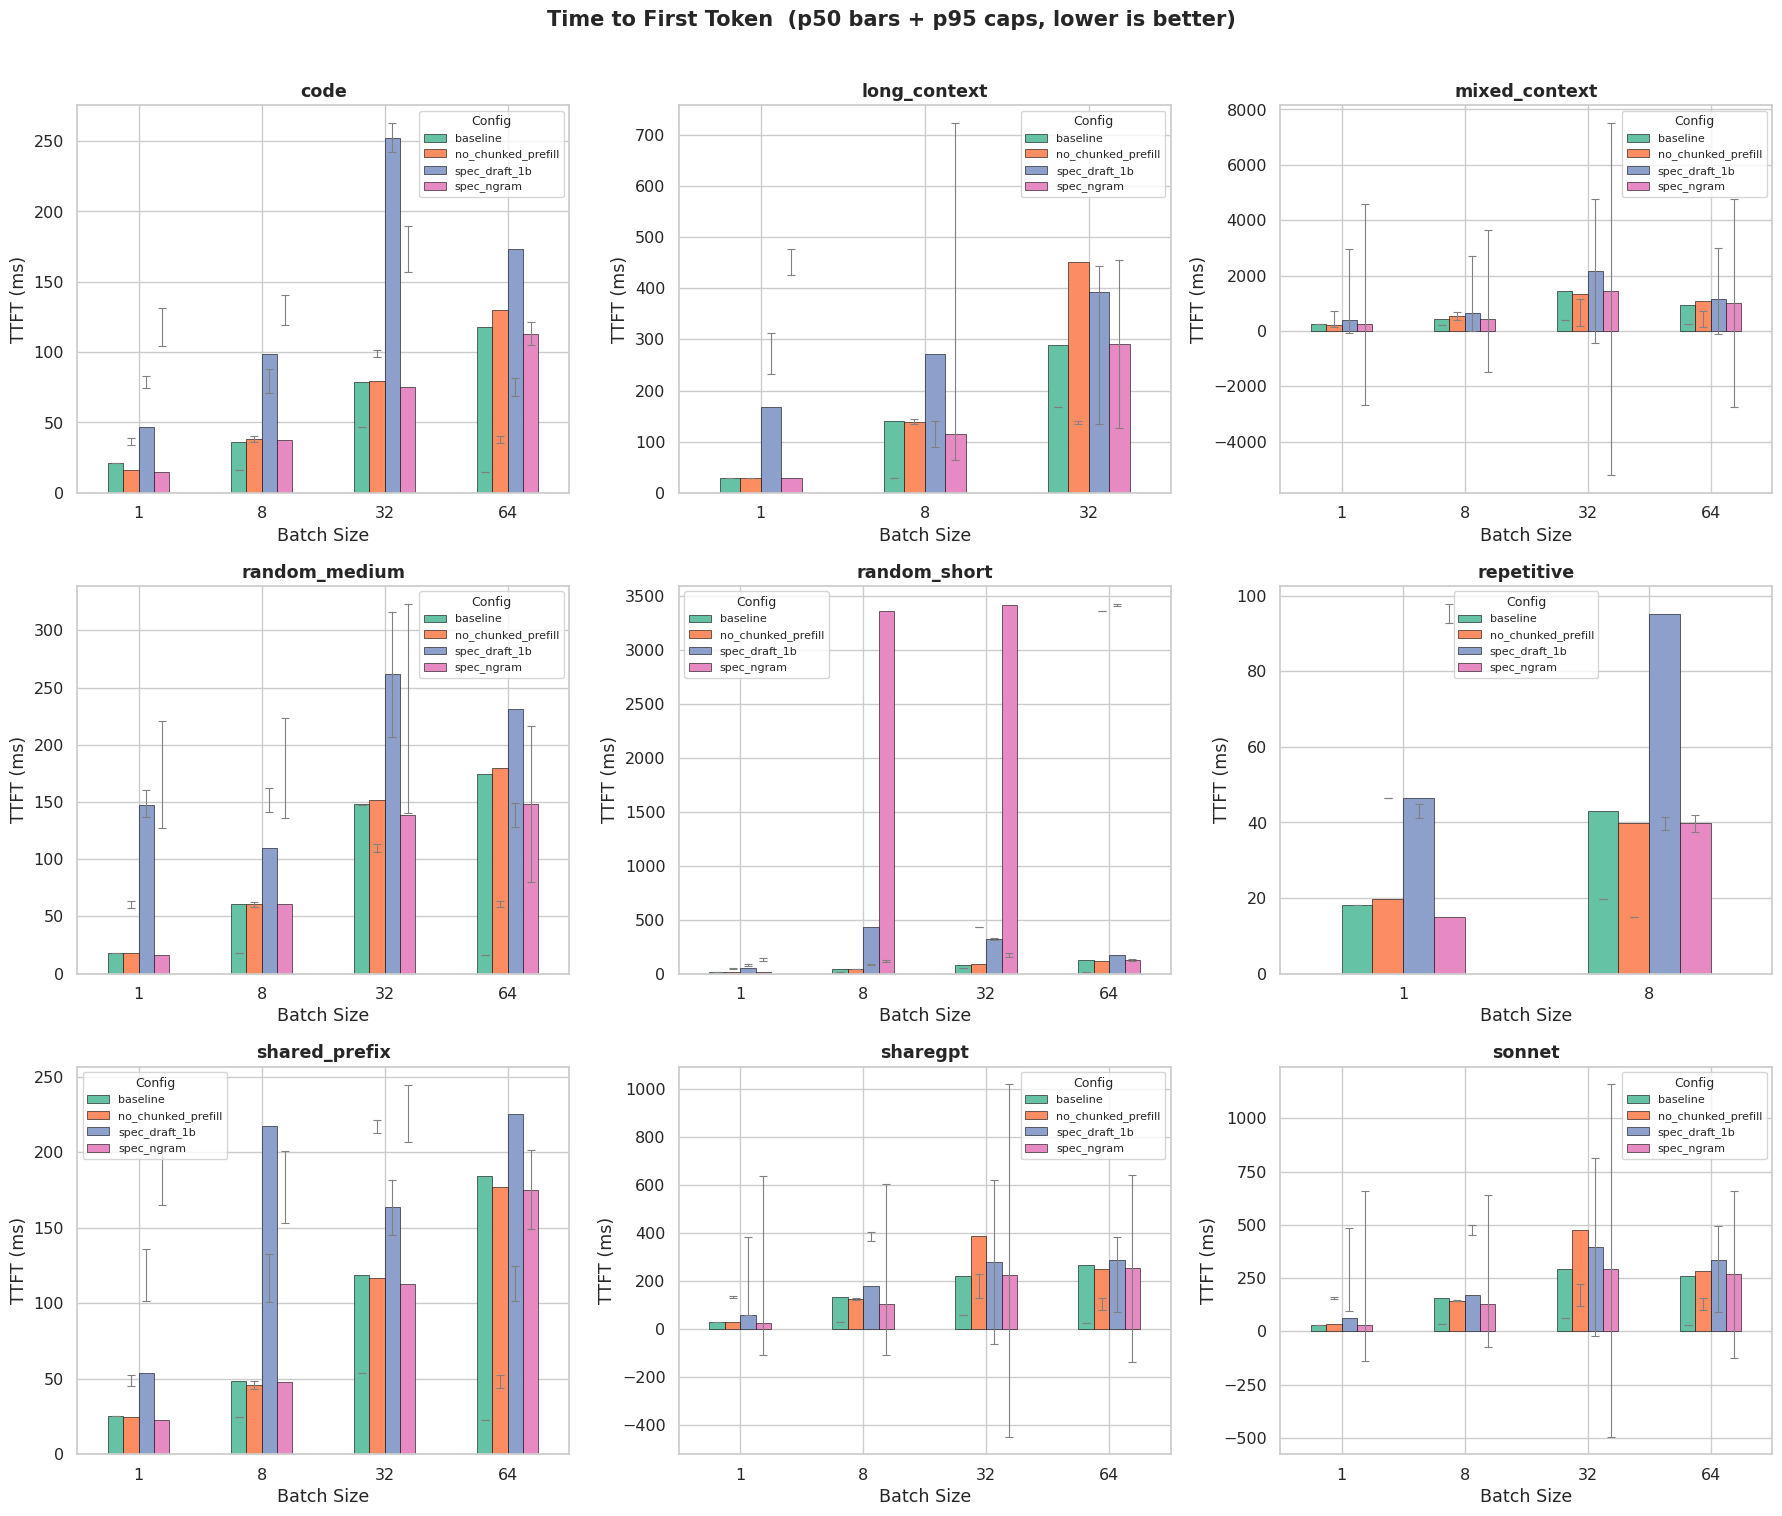

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),
                         squeeze=False)

for idx, wl in enumerate(workloads):
    ax = axes[idx // ncols][idx % ncols]
    sub = df_all[df_all["workload_name"] == wl].copy()

    # p50 bars
    pivot50 = sub.pivot_table(
        index="batch_size", columns="config_name",
        values="ttft_p50_ms", aggfunc="first",
    ).reindex(columns=CONFIG_ORDER)
    bars = pivot50.plot.bar(ax=ax, color=PALETTE[:len(CONFIG_ORDER)],
                            edgecolor="black", linewidth=0.4)

    # overlay p95 as error caps
    pivot95 = sub.pivot_table(
        index="batch_size", columns="config_name",
        values="ttft_p95_ms", aggfunc="first",
    ).reindex(columns=CONFIG_ORDER)
    for j, cfg in enumerate(CONFIG_ORDER):
        if cfg in pivot50.columns and cfg in pivot95.columns:
            x_positions = [p.get_x() + p.get_width() / 2
                           for p in bars.patches[j::len(CONFIG_ORDER)]]
            y_lo = pivot50[cfg].values
            y_hi = pivot95[cfg].values
            yerr = np.clip(y_hi - y_lo, 0, None)
            ax.errorbar(x_positions[:len(y_lo)], y_lo, yerr=yerr, fmt="none",
                        ecolor="gray", capsize=3, capthick=0.8, linewidth=0.8)

    ax.set_title(wl, fontweight="bold")
    ax.set_ylabel("TTFT (ms)")
    ax.set_xlabel("Batch Size")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Config", fontsize=8, title_fontsize=9)

for idx in range(n_wl, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Time to First Token  (p50 bars + p95 caps, lower is better)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_ttft.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Inter-Token Latency (ITL) Comparison

ITL p50 with p95 error caps. Lower is better for streaming applications.

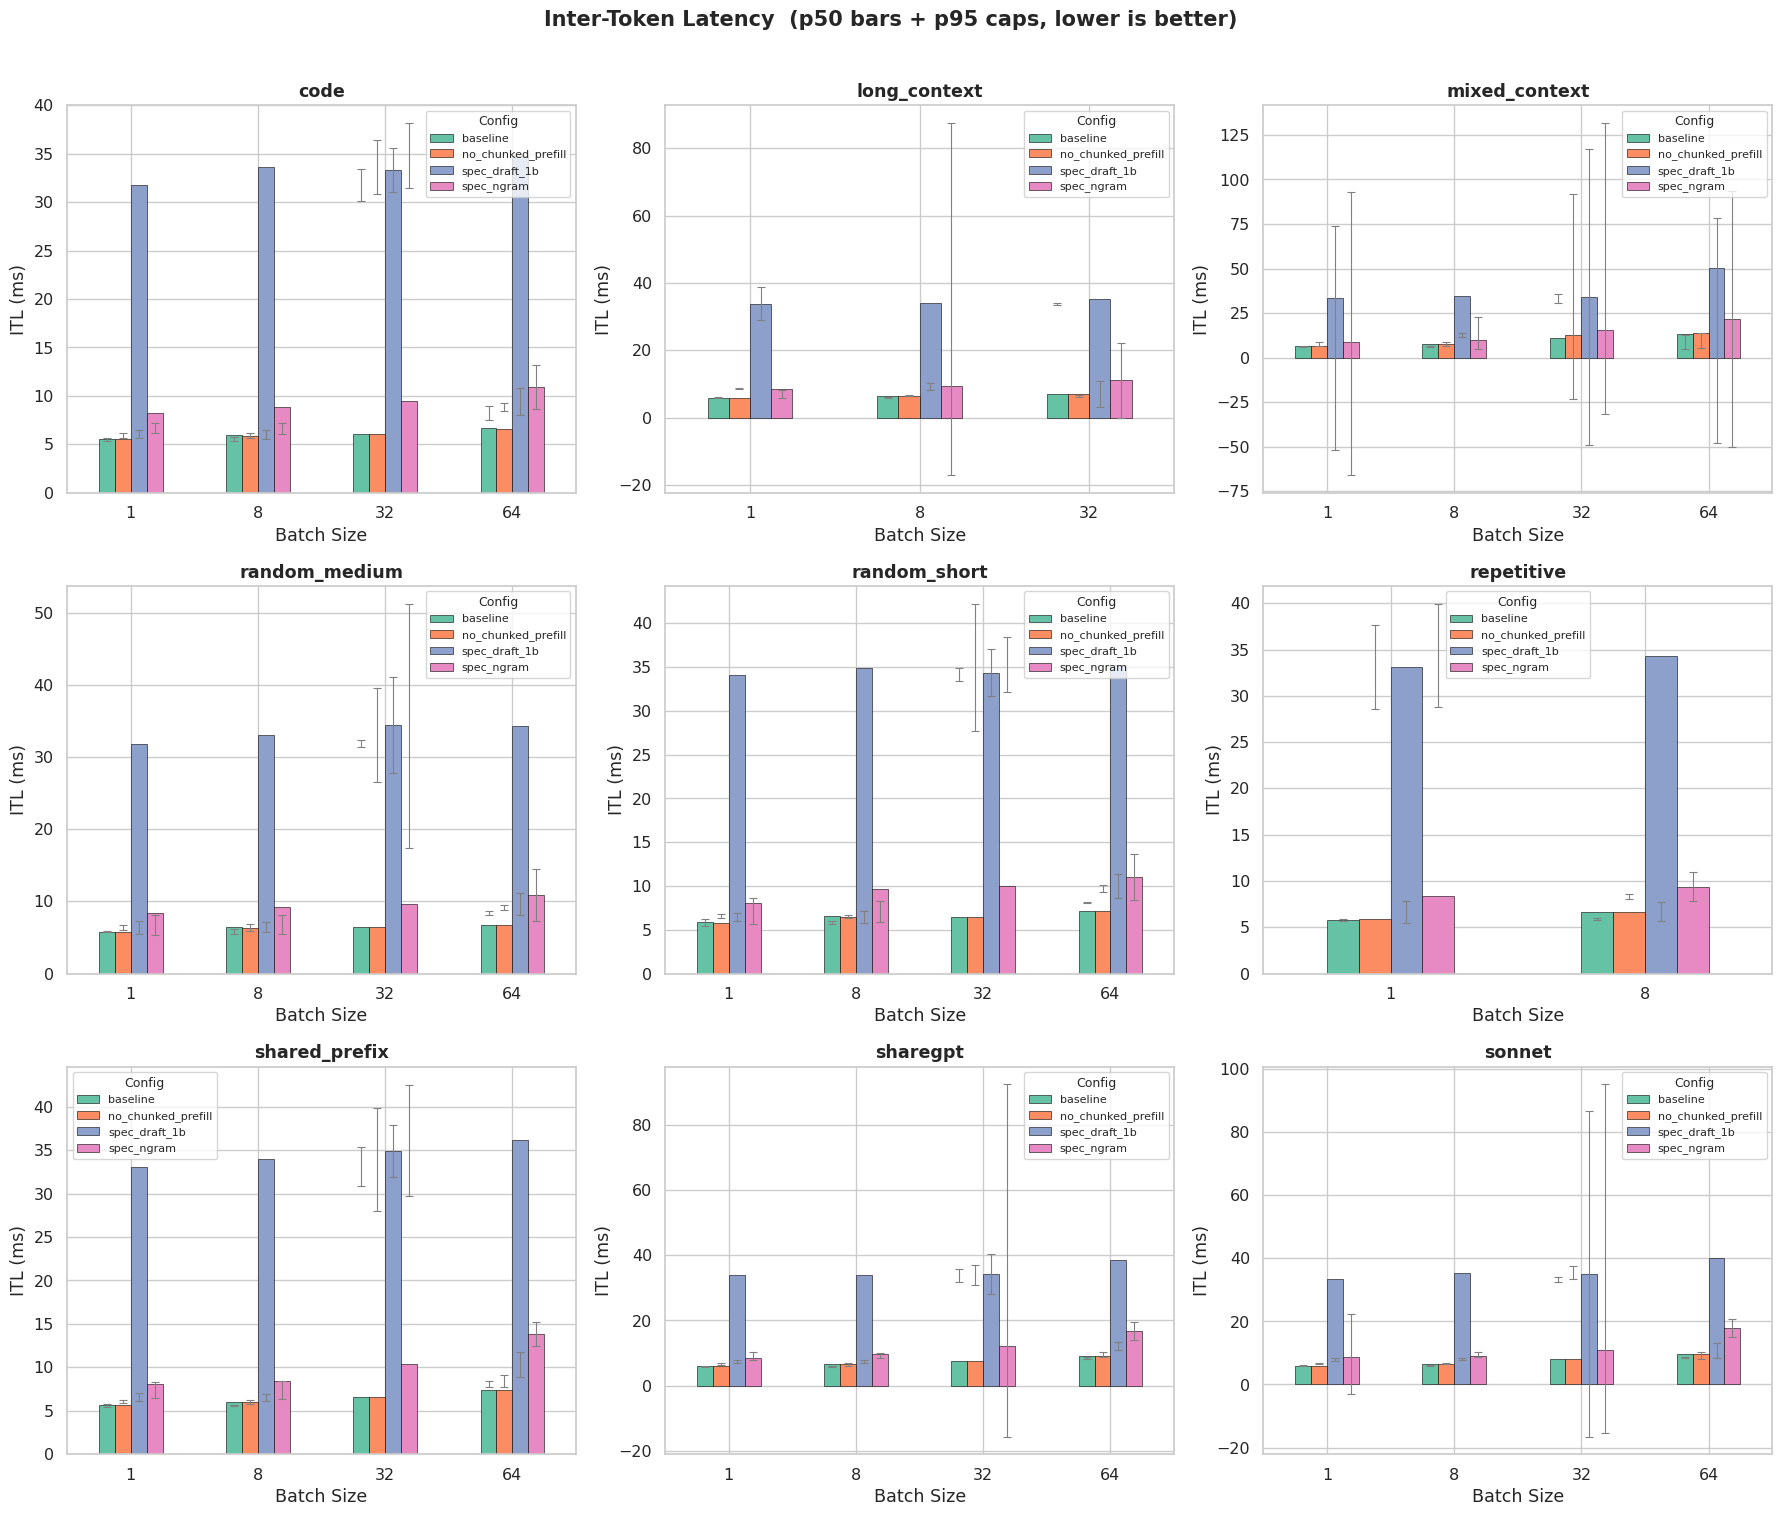

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),
                         squeeze=False)

for idx, wl in enumerate(workloads):
    ax = axes[idx // ncols][idx % ncols]
    sub = df_all[df_all["workload_name"] == wl].copy()

    pivot50 = sub.pivot_table(
        index="batch_size", columns="config_name",
        values="itl_p50_ms", aggfunc="first",
    ).reindex(columns=CONFIG_ORDER)
    bars = pivot50.plot.bar(ax=ax, color=PALETTE[:len(CONFIG_ORDER)],
                            edgecolor="black", linewidth=0.4)

    pivot95 = sub.pivot_table(
        index="batch_size", columns="config_name",
        values="itl_p95_ms", aggfunc="first",
    ).reindex(columns=CONFIG_ORDER)
    for j, cfg in enumerate(CONFIG_ORDER):
        if cfg in pivot50.columns and cfg in pivot95.columns:
            x_positions = [p.get_x() + p.get_width() / 2
                           for p in bars.patches[j::len(CONFIG_ORDER)]]
            y_lo = pivot50[cfg].values
            y_hi = pivot95[cfg].values
            yerr = np.clip(y_hi - y_lo, 0, None)
            ax.errorbar(x_positions[:len(y_lo)], y_lo, yerr=yerr, fmt="none",
                        ecolor="gray", capsize=3, capthick=0.8, linewidth=0.8)

    ax.set_title(wl, fontweight="bold")
    ax.set_ylabel("ITL (ms)")
    ax.set_xlabel("Batch Size")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Config", fontsize=8, title_fontsize=9)

for idx in range(n_wl, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Inter-Token Latency  (p50 bars + p95 caps, lower is better)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_itl.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Speedup vs Baseline

Heatmaps showing how much faster (or slower) each speculative config is
relative to the baseline. Values > 1.0 mean the spec config is faster.

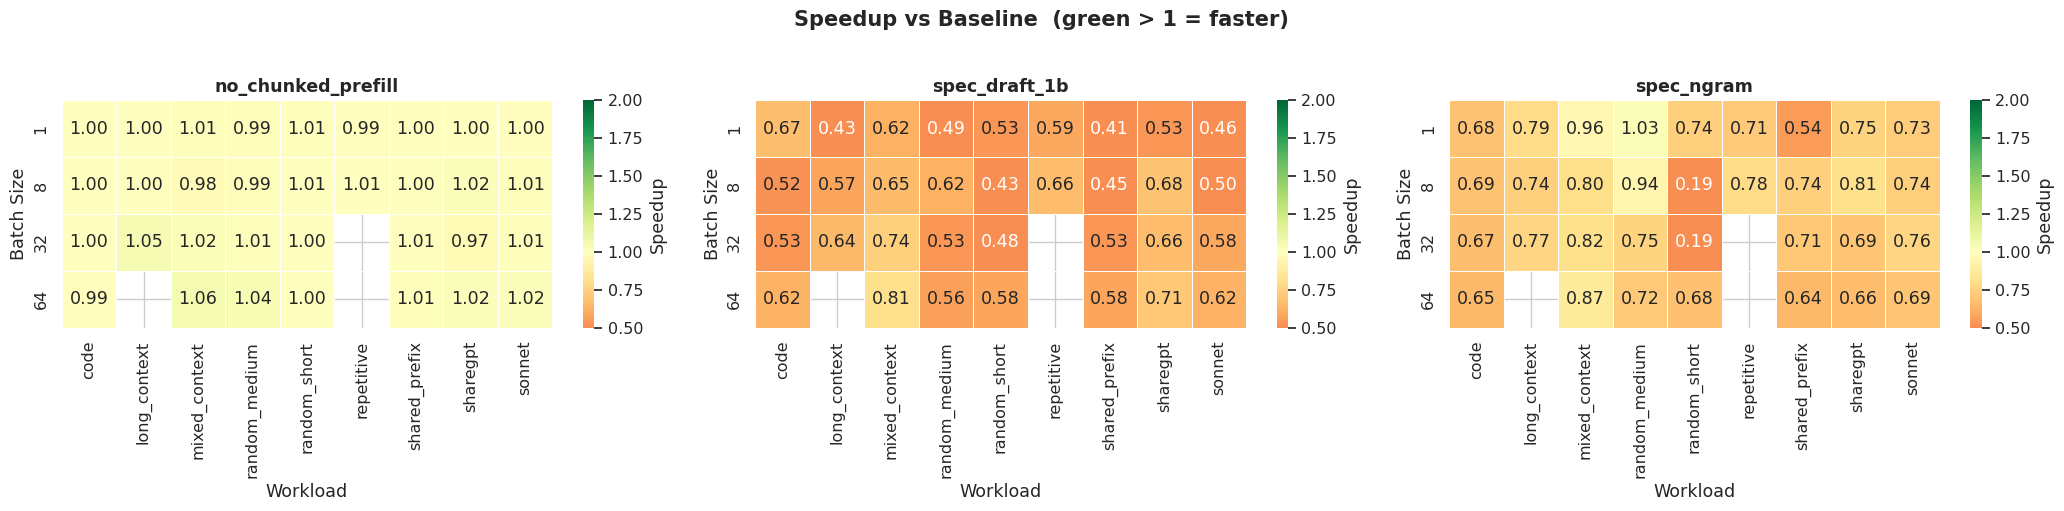

In [ ]:
spec_configs = [c for c in CONFIG_ORDER if c != "baseline"]
n_spec = len(spec_configs)

if n_spec > 0:
    fig, axes = plt.subplots(1, n_spec, figsize=(7 * n_spec, 5), squeeze=False)

    for i, cfg in enumerate(spec_configs):
        ax = axes[0][i]
        sub = df_all[df_all["config_name"] == cfg].copy()
        pivot = sub.pivot_table(
            index="batch_size", columns="workload_name",
            values="speedup_vs_baseline", aggfunc="first",
        )
        # Sort columns for consistency
        pivot = pivot.reindex(columns=sorted(pivot.columns))

        sns.heatmap(
            pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0,
            linewidths=0.5, ax=ax, vmin=0.5, vmax=2.0,
            cbar_kws={"label": "Speedup"},
        )
        ax.set_title(f"{cfg}", fontweight="bold")
        ax.set_ylabel("Batch Size")
        ax.set_xlabel("Workload")

    fig.suptitle("Speedup vs Baseline  (green > 1 = faster)",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("plot_speedup_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No speculative configs to compare.")

## 14. Latency vs Throughput Tradeoff

Scatter plot of TTFT (latency) against throughput. Ideal configs appear
in the **bottom-right** (high throughput, low latency).

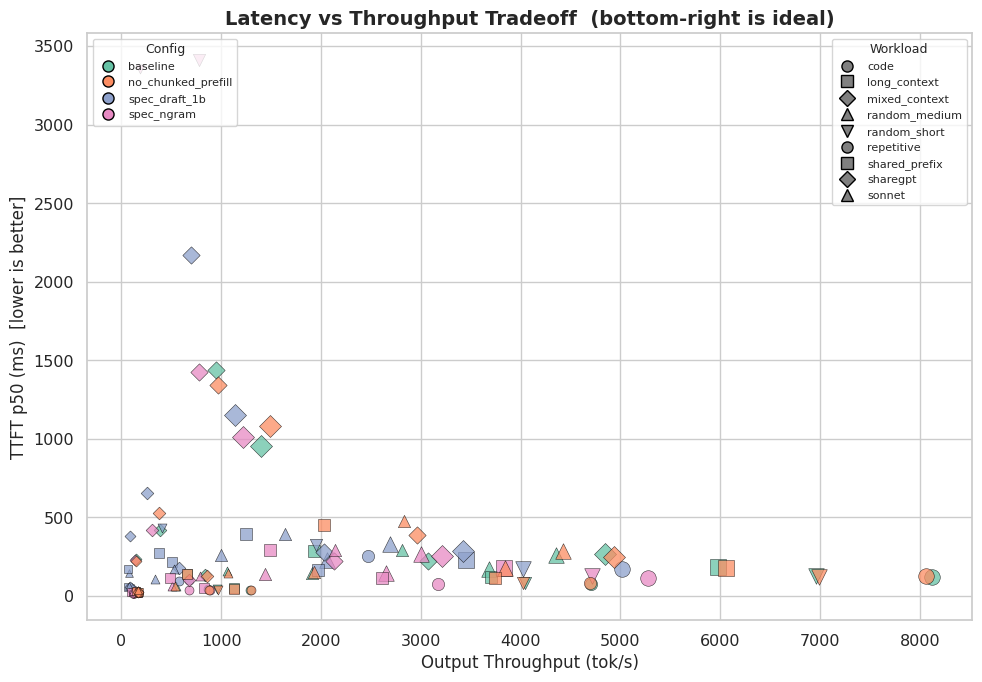

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

markers = ["o", "s", "D", "^", "v"]
wl_markers = {wl: markers[i % len(markers)] for i, wl in enumerate(workloads)}
cfg_colors = {c: PALETTE[i] for i, c in enumerate(CONFIG_ORDER)}

for _, row in df_all.iterrows():
    tp = row["throughput_output_tok_s"]
    ttft = row["ttft_p50_ms"]
    if pd.isna(tp) or pd.isna(ttft) or tp <= 0:
        continue
    ax.scatter(
        tp, ttft,
        c=[cfg_colors[row["config_name"]]],
        marker=wl_markers[row["workload_name"]],
        s=30 + row["batch_size"] * 1.5,
        alpha=0.75, edgecolors="black", linewidth=0.4,
    )

# Legends
from matplotlib.lines import Line2D
cfg_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=cfg_colors[c],
           markersize=8, markeredgecolor="black", linewidth=0.4, label=c)
    for c in CONFIG_ORDER
]
wl_handles = [
    Line2D([0], [0], marker=wl_markers[w], color="w", markerfacecolor="gray",
           markersize=8, markeredgecolor="black", linewidth=0.4, label=w)
    for w in workloads
]
legend1 = ax.legend(handles=cfg_handles, title="Config", loc="upper left",
                     fontsize=8, title_fontsize=9)
ax.add_artist(legend1)
ax.legend(handles=wl_handles, title="Workload", loc="upper right",
          fontsize=8, title_fontsize=9)

ax.set_xlabel("Output Throughput (tok/s)", fontsize=12)
ax.set_ylabel("TTFT p50 (ms)  [lower is better]", fontsize=12)
ax.set_title("Latency vs Throughput Tradeoff  (bottom-right is ideal)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_latency_vs_throughput.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Goodput & Reliability

Compares raw throughput vs goodput (successful tokens only) and shows
success rates across configurations.

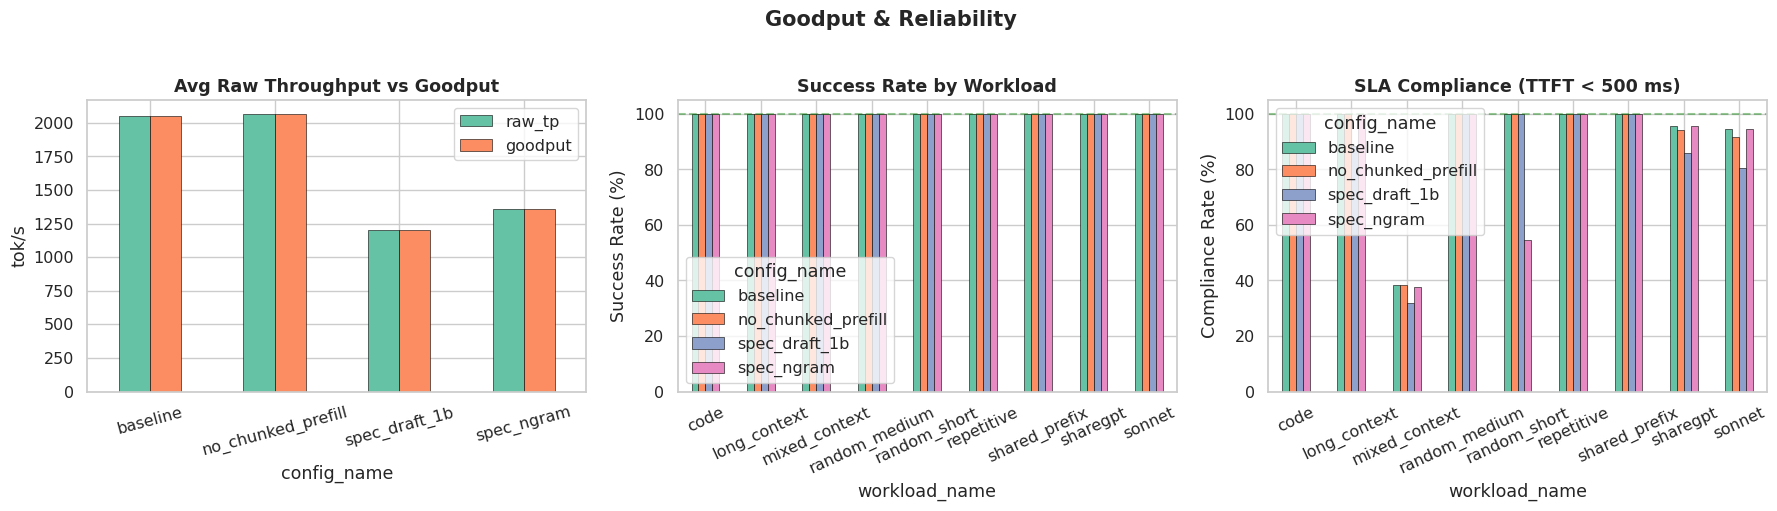

In [ ]:
goodput_col = "goodput_goodput_tok_s"
success_col = "goodput_success_rate"
sla_col = "goodput_sla_compliance_rate"

has_goodput = goodput_col in df_all.columns and df_all[goodput_col].notna().any()
has_success = success_col in df_all.columns and df_all[success_col].notna().any()

if has_goodput or has_success:
    n_panels = sum([has_goodput, has_success, sla_col in df_all.columns])
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), squeeze=False)
    panel = 0

    # -- Raw throughput vs Goodput --
    if has_goodput:
        ax = axes[0][panel]
        panel += 1
        compare = df_all.groupby("config_name").agg(
            raw_tp=("throughput_output_tok_s", "mean"),
            goodput=(goodput_col, "mean"),
        )
        compare.plot.bar(ax=ax, color=[PALETTE[0], PALETTE[1]],
                         edgecolor="black", linewidth=0.4)
        ax.set_title("Avg Raw Throughput vs Goodput", fontweight="bold")
        ax.set_ylabel("tok/s")
        ax.tick_params(axis="x", rotation=15)

    # -- Success rate by config + workload --
    if has_success:
        ax = axes[0][panel]
        panel += 1
        pivot_sr = df_all.pivot_table(
            index="workload_name", columns="config_name",
            values=success_col, aggfunc="mean",
        ).reindex(columns=CONFIG_ORDER)
        pivot_sr.plot.bar(ax=ax, color=PALETTE[:len(CONFIG_ORDER)],
                          edgecolor="black", linewidth=0.4)
        ax.set_title("Success Rate by Workload", fontweight="bold")
        ax.set_ylabel("Success Rate (%)")
        ax.set_ylim(0, 105)
        ax.axhline(100, color="green", linestyle="--", alpha=0.4)
        ax.tick_params(axis="x", rotation=25)

    # -- SLA compliance --
    if sla_col in df_all.columns and df_all[sla_col].notna().any():
        ax = axes[0][panel]
        panel += 1
        pivot_sla = df_all.pivot_table(
            index="workload_name", columns="config_name",
            values=sla_col, aggfunc="mean",
        ).reindex(columns=CONFIG_ORDER)
        pivot_sla.plot.bar(ax=ax, color=PALETTE[:len(CONFIG_ORDER)],
                           edgecolor="black", linewidth=0.4)
        ax.set_title("SLA Compliance (TTFT < 500 ms)", fontweight="bold")
        ax.set_ylabel("Compliance Rate (%)")
        ax.set_ylim(0, 105)
        ax.axhline(100, color="green", linestyle="--", alpha=0.4)
        ax.tick_params(axis="x", rotation=25)

    fig.suptitle("Goodput & Reliability", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("plot_goodput.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No goodput/success-rate data available.")

## 16. KV Cache Analysis

KV cache utilization and prefix-cache hit rates (when available).

In [ ]:
kv_util_col = "kv_cache_utilization_pct"
prefix_col = "kv_prefix_cache_hit_rate"

has_kv = kv_util_col in df_all.columns and df_all[kv_util_col].notna().any()
has_prefix = prefix_col in df_all.columns and df_all[prefix_col].notna().any()

if has_kv or has_prefix:
    n_panels = sum([has_kv, has_prefix])
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5), squeeze=False)
    panel = 0

    if has_kv:
        ax = axes[0][panel]
        panel += 1
        pivot_kv = df_all.pivot_table(
            index="batch_size", columns="config_name",
            values=kv_util_col, aggfunc="mean",
        ).reindex(columns=CONFIG_ORDER)
        pivot_kv.plot.bar(ax=ax, color=PALETTE[:len(CONFIG_ORDER)],
                          edgecolor="black", linewidth=0.4)
        ax.set_title("KV Cache Utilization by Batch Size", fontweight="bold")
        ax.set_ylabel("Utilization (%)")
        ax.set_xlabel("Batch Size")
        ax.tick_params(axis="x", rotation=0)

    if has_prefix:
        ax = axes[0][panel]
        panel += 1
        pivot_prefix = df_all.pivot_table(
            index="workload_name", columns="config_name",
            values=prefix_col, aggfunc="mean",
        ).reindex(columns=CONFIG_ORDER)
        pivot_prefix.plot.bar(ax=ax, color=PALETTE[:len(CONFIG_ORDER)],
                              edgecolor="black", linewidth=0.4)
        ax.set_title("Prefix Cache Hit Rate by Workload", fontweight="bold")
        ax.set_ylabel("Hit Rate (%)")
        ax.set_xlabel("Workload")
        ax.tick_params(axis="x", rotation=25)

    fig.suptitle("KV Cache Analysis", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("plot_kv_cache.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No KV cache metrics available.")

No KV cache metrics available.


## 17. Request Latency Distribution

Mean request latency across workloads, grouped by config and batch size.

In [ ]:
lat_col = "request_latency_mean_ms"

if lat_col in df_all.columns and df_all[lat_col].notna().any():
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),
                             squeeze=False)
    for idx, wl in enumerate(workloads):
        ax = axes[idx // ncols][idx % ncols]
        sub = df_all[df_all["workload_name"] == wl]
        pivot = sub.pivot_table(
            index="batch_size", columns="config_name",
            values=lat_col, aggfunc="first",
        ).reindex(columns=CONFIG_ORDER)
        pivot.plot.bar(ax=ax, color=PALETTE[:len(CONFIG_ORDER)],
                       edgecolor="black", linewidth=0.4)
        ax.set_title(wl, fontweight="bold")
        ax.set_ylabel("Mean Request Latency (ms)")
        ax.set_xlabel("Batch Size")
        ax.tick_params(axis="x", rotation=0)
        ax.legend(title="Config", fontsize=8, title_fontsize=9)

    for idx in range(n_wl, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Mean Request Latency  (lower is better)",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("plot_request_latency.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No request latency data available.")

No request latency data available.


## 18. Scaling Efficiency

Line plots showing how throughput scales with batch size for each config.
Ideal scaling would be linear.

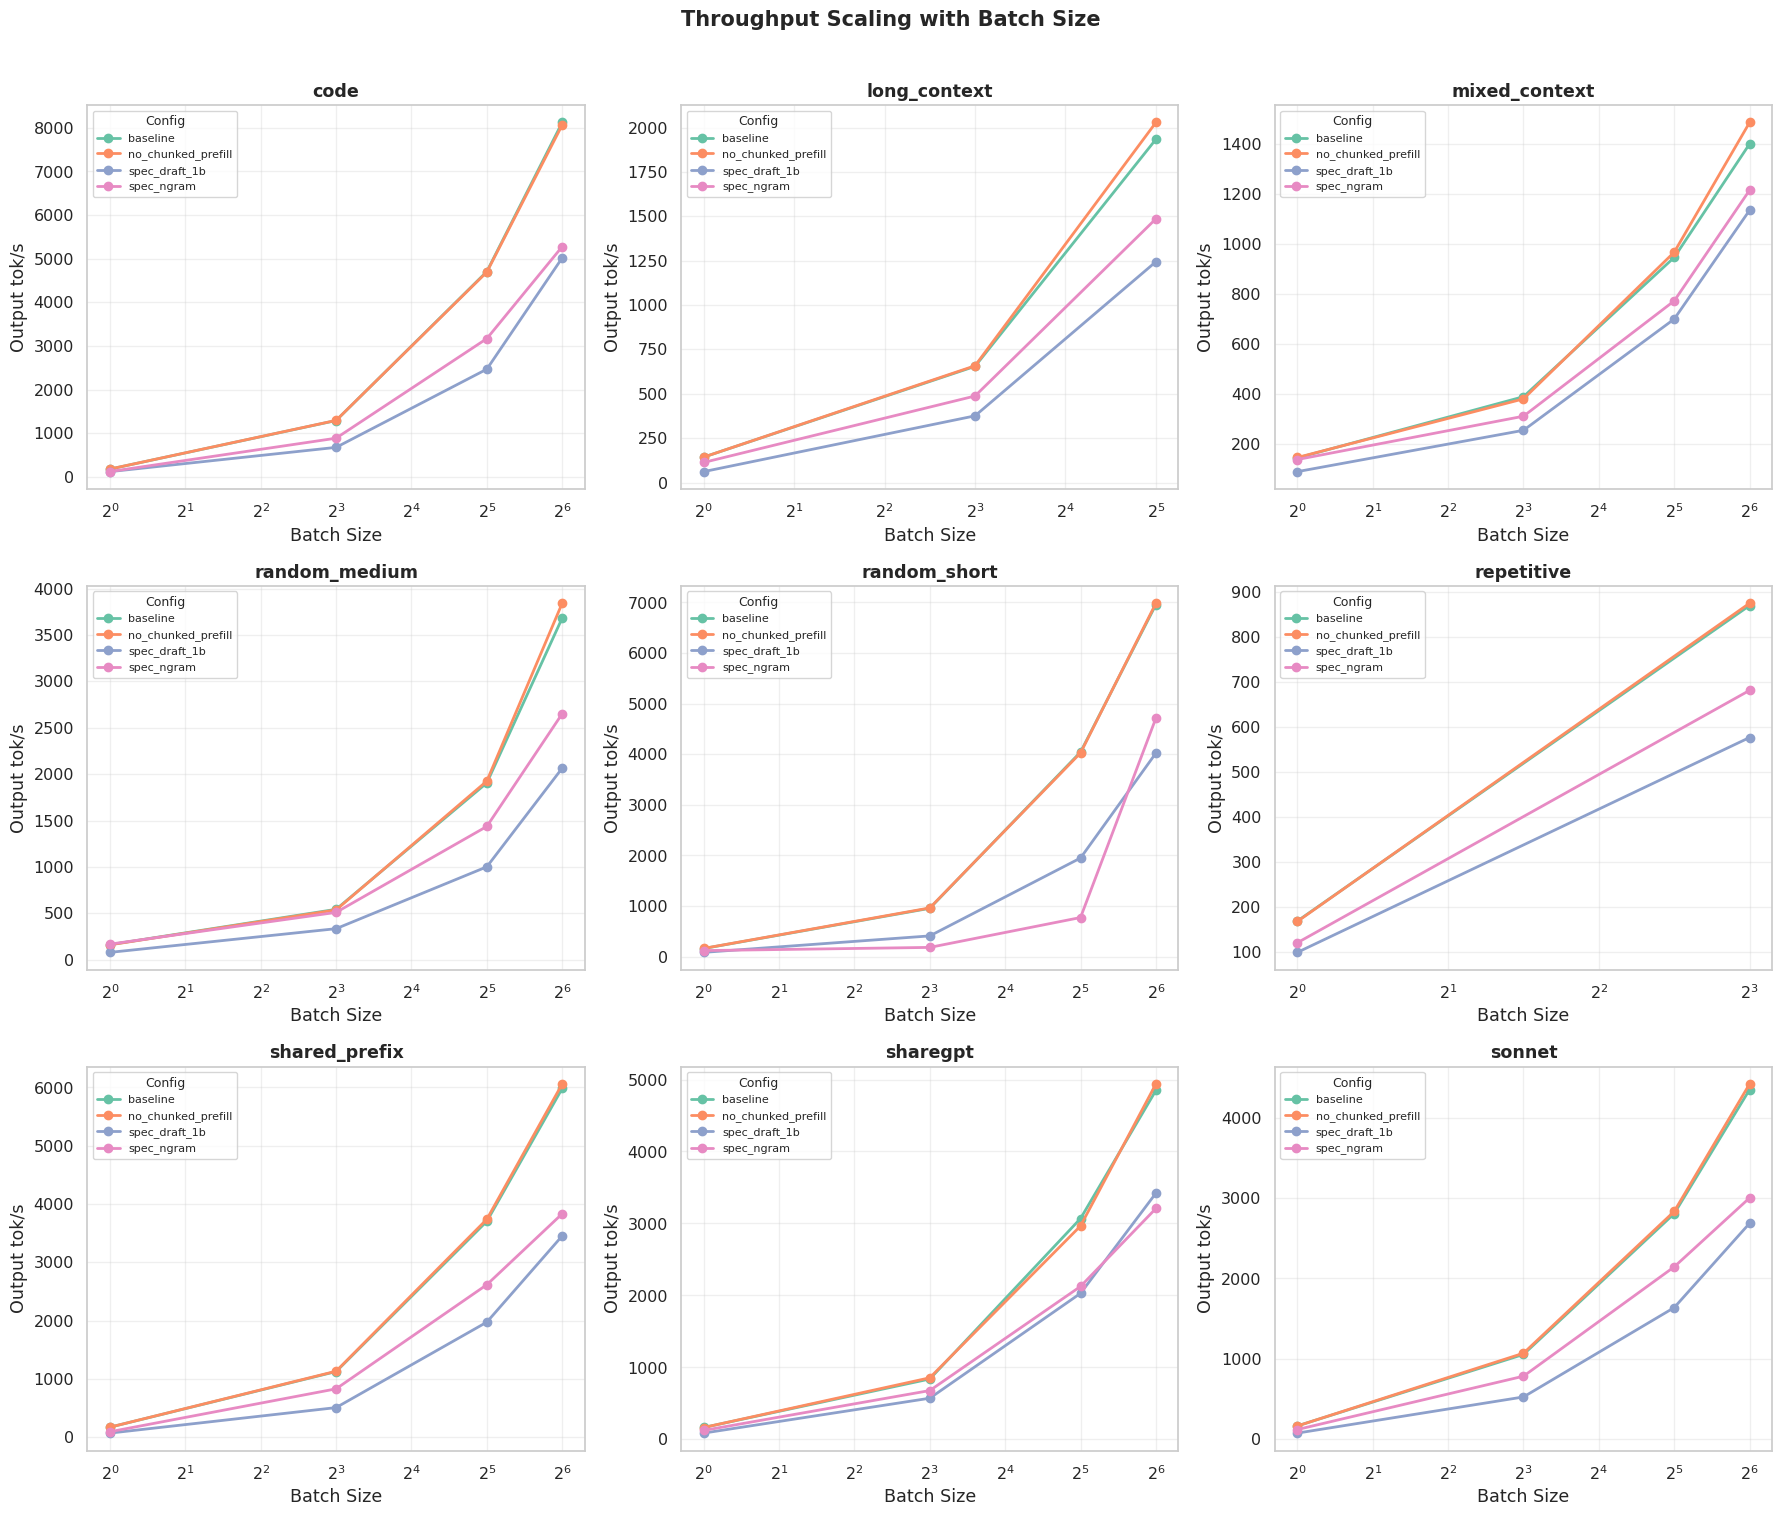

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),
                         squeeze=False)

for idx, wl in enumerate(workloads):
    ax = axes[idx // ncols][idx % ncols]
    sub = df_all[df_all["workload_name"] == wl]

    for i, cfg in enumerate(CONFIG_ORDER):
        cfg_sub = sub[sub["config_name"] == cfg].sort_values("batch_size")
        if cfg_sub.empty:
            continue
        ax.plot(
            cfg_sub["batch_size"], cfg_sub["throughput_output_tok_s"],
            marker="o", label=cfg, color=PALETTE[i], linewidth=2,
            markersize=6,
        )

    ax.set_title(wl, fontweight="bold")
    ax.set_ylabel("Output tok/s")
    ax.set_xlabel("Batch Size")
    ax.set_xscale("log", base=2)
    ax.legend(title="Config", fontsize=8, title_fontsize=9)
    ax.grid(True, alpha=0.3)

for idx in range(n_wl, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Throughput Scaling with Batch Size",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

## 19. Comprehensive Summary

Best configuration per workload (by throughput and by TTFT), plus an
overall metrics comparison table.

In [ ]:
print("=" * 70)
print("BEST CONFIG PER WORKLOAD  (by output throughput)")
print("=" * 70)

for wl in workloads:
    sub = df_all[df_all["workload_name"] == wl]
    if sub.empty:
        continue
    best = sub.loc[sub["throughput_output_tok_s"].idxmax()]
    print(f"  {wl:>20s}:  {best['config_name']} "
          f"(batch={int(best['batch_size'])})  "
          f"{best['throughput_output_tok_s']:.1f} tok/s")

print()
print("=" * 70)
print("BEST CONFIG PER WORKLOAD  (by lowest TTFT p50)")
print("=" * 70)

for wl in workloads:
    sub = df_all[df_all["workload_name"] == wl].dropna(subset=["ttft_p50_ms"])
    if sub.empty:
        continue
    best = sub.loc[sub["ttft_p50_ms"].idxmin()]
    print(f"  {wl:>20s}:  {best['config_name']} "
          f"(batch={int(best['batch_size'])})  "
          f"{best['ttft_p50_ms']:.1f} ms")

print()
print("=" * 70)
print("OVERALL METRICS BY CONFIG  (averaged across all workloads & batches)")
print("=" * 70)

summary_metrics = ["throughput_output_tok_s", "ttft_p50_ms", "itl_p50_ms",
                   "request_latency_mean_ms", "speedup_vs_baseline"]
available = [m for m in summary_metrics if m in df_all.columns]

summary = df_all.groupby("config_name")[available].mean().round(2)
print(summary.to_string())

# Per-workload throughput pivot
print()
print("=" * 70)
print("THROUGHPUT PIVOT  (output tok/s, rows=workload+batch, cols=config)")
print("=" * 70)
tp_pivot = df_all.pivot_table(
    index=["workload_name", "batch_size"], columns="config_name",
    values="throughput_output_tok_s", aggfunc="first",
).reindex(columns=CONFIG_ORDER)
print(tp_pivot.to_string())

BEST CONFIG PER WORKLOAD  (by output throughput)
                  code:  baseline (batch=64)  8121.8 tok/s
          long_context:  no_chunked_prefill (batch=32)  2028.3 tok/s
         mixed_context:  no_chunked_prefill (batch=64)  1487.0 tok/s
         random_medium:  no_chunked_prefill (batch=64)  3841.5 tok/s
          random_short:  no_chunked_prefill (batch=64)  6985.6 tok/s
            repetitive:  no_chunked_prefill (batch=8)  875.2 tok/s
         shared_prefix:  no_chunked_prefill (batch=64)  6059.9 tok/s
              sharegpt:  no_chunked_prefill (batch=64)  4938.4 tok/s
                sonnet:  no_chunked_prefill (batch=64)  4420.8 tok/s

BEST CONFIG PER WORKLOAD  (by lowest TTFT p50)
                  code:  spec_ngram (batch=1)  15.0 ms
          long_context:  spec_ngram (batch=1)  28.0 ms
         mixed_context:  no_chunked_prefill (batch=1)  220.4 ms
         random_medium:  spec_ngram (batch=1)  16.2 ms
          random_short:  spec_ngram (batch=1)  15.3 ms
          

---
## 20. Export All Results

Downloads the per-config CSVs, combined CSV, and all plot PNGs.

In [ ]:
import glob
from google.colab import files

export_files = [
    "results_baseline.csv",
    "results_spec_draft_1b.csv",
    "results_spec_ngram.csv",
    "results_no_chunked_prefill.csv",
]
# Pick up the combined CSV (timestamped)
export_files += sorted(glob.glob("results_combined_*.csv"))[-1:]
# Pick up all plots
export_files += sorted(glob.glob("plot_*.png"))

print("Downloading:")
for f in export_files:
    if os.path.exists(f):
        print(f"  {f}")
        files.download(f)
    else:
        print(f"  {f}  (not found, skipping)")

Downloading:
  results_baseline.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  results_spec_draft_1b.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  plot_ttft.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>